# **Client Analysis for Floor Cleaner Sale**


In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2

***Load the Excel File using Pandas***

In [120]:
df=pd.read_excel("Leads.xlsx")
df.head()

,query,name,name_for_emails,site,subtypes,category,type,phone,full_address,borough,...,menu_link,order_links,location_link,location_reviews_link,place_id,google_id,cid,kgmid,reviews_id,located_google_id
0,"hotel, 110089, North West Delhi, Delhi, IN",GALLIVANTO INN,Gallivanto Inn,http://www.gallivantoinn.com/,"Hotel, Bed & breakfast, Guest house, Inn, Lodg...",hotels,Hotel,+91 98117 66161,"Building no- 60, near primary school, Badli, R...","Badli, Rohini",...,NaN,NaN,https://www.google.com/maps/place/GALLIVANTO+I...,https://www.google.com/maps/place/GALLIVANTO+I...,ChIJBUyBs_EBDTkR6NDsh_942IY,0x390d01f1b3814c05:0x86d878ff87ecd0e8,9716649234944282856,/g/11smkt3hxv,-8.730095e+18,NaN
1,"hotel, 110089, North West Delhi, Delhi, IN",Hotel Gray Saffron,Hotel Gray Saffron,NaN,Hotel,hotels,Hotel,NaN,"H1, B7, Sector 18, Rohini, New Delhi, Delhi, 1...","Sector 18, Rohini",...,NaN,NaN,https://www.google.com/maps/place/Hotel+Gray+S...,https://www.google.com/maps/place/Hotel+Gray+S...,ChIJgzk4YxABDTkR13wV9wUJPtY,0x390d011063383983:0xd63e0905f7157cd7,15437786493897506007,/g/11mh_6grvh,-3.008958e+18,NaN
2,"hotel, 110089, North West Delhi, Delhi, IN",AP Holidays,Ap Holidays,https://apholidays.in/,Hotel,hotels,Hotel,+91 92189 21855,"Plot No. 8, Pocket 8B, YES Bank Building, Sect...","Sector 15, Rohini",...,NaN,NaN,https://www.google.com/maps/place/AP+Holidays/...,https://www.google.com/maps/place/AP+Holidays/...,ChIJ486HNRMBDTkRM1sl8rwuie4,0x390d01133587cee3:0xee892ebcf2255b33,17188320841887472435,/g/11c5x7xp06,-1.258423e+18,NaN
3,"hotel, 110089, North West Delhi, Delhi, IN",Hotel Park Lane,Hotel Park Lane,NaN,Asian restaurant,restaurants,Asian restaurant,NaN,"Pocket 8(B, Plot 2, next to Saroj Hospital, Se...","Sector 19, Rohini",...,NaN,NaN,https://www.google.com/maps/place/Hotel+Park+L...,https://www.google.com/maps/place/Hotel+Park+L...,ChIJORPjeQABDTkR6RApV-gBC80,0x390d010079e31339:0xcd0b01e8572910e9,14774905099925393641,/g/11vwprkgpl,-3.671839e+18,NaN
4,"hotel, 110089, North West Delhi, Delhi, IN","FabHotel The Chaitanyas - Hotel in Rohini, New...",Fabhotel The Chaitanyas Hotel In Rohini New Delhi,https://www.fabhotels.com/hotels-in-new-delhi/...,Hotel,hotels,Hotel,+91 70424 24242,"H-3/25, Sector 18, Rohini, New Delhi, Delhi, 1...","Sector 18, Rohini",...,NaN,NaN,https://www.google.com/maps/place/FabHotel+The...,https://www.google.com/maps/place/FabHotel+The...,ChIJ14Hw8TkBDTkRkLqc_kOi0fY,0x390d0139f1f081d7:0xf6d1a243fe9cba90,17785174816380992144,/g/11rtd6n_5x,-6.615693e+17,NaN


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 66 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   query                         300 non-null    object 
 1   name                          300 non-null    object 
 2   name_for_emails               300 non-null    object 
 3   site                          192 non-null    object 
 4   subtypes                      299 non-null    object 
 5   category                      299 non-null    object 
 6   type                          299 non-null    object 
 7   phone                         262 non-null    object 
 8   full_address                  300 non-null    object 
 9   borough                       300 non-null    object 
 10  street                        286 non-null    object 
 11  city                          300 non-null    object 
 12  postal_code                   300 non-null    int64  
 13  state

In [122]:
df.columns

Index(['query', 'name', 'name_for_emails', 'site', 'subtypes', 'category',
       'type', 'phone', 'full_address', 'borough', 'street', 'city',
       'postal_code', 'state', 'us_state', 'country', 'country_code',
       'latitude', 'longitude', 'h3', 'time_zone', 'plus_code', 'area_service',
       'rating', 'reviews', 'reviews_link', 'reviews_tags',
       'reviews_per_score', 'reviews_per_score_1', 'reviews_per_score_2',
       'reviews_per_score_3', 'reviews_per_score_4', 'reviews_per_score_5',
       'photos_count', 'photo', 'street_view', 'located_in', 'working_hours',
       'working_hours_csv_compatible', 'working_hours_old_format',
       'other_hours', 'popular_times', 'business_status', 'about', 'range',
       'prices', 'posts', 'logo', 'description', 'typical_time_spent',
       'verified', 'owner_id', 'owner_title', 'owner_link',
       'reservation_links', 'booking_appointment_link', 'menu_link',
       'order_links', 'location_link', 'location_reviews_link', 'place_id',

***Show total rows, columns, and nulls per column***

In [123]:
print(f"Rows:{df.shape[0]}")
print(f"Columns:{df.shape[1]}")
print("\nNulls per column -\n"
        "----------------")
null_counts_dict = df.isnull().sum().to_dict()
for col, null_count in null_counts_dict.items():
    print(f"{col}: {null_count}")

Rows:300
Columns:66

Nulls per column -
----------------
query: 0
name: 0
name_for_emails: 0
site: 108
subtypes: 1
category: 1
type: 1
phone: 38
full_address: 0
borough: 0
street: 14
city: 0
postal_code: 0
state: 0
us_state: 300
country: 0
country_code: 0
latitude: 0
longitude: 0
h3: 0
time_zone: 0
plus_code: 300
area_service: 0
rating: 29
reviews: 29
reviews_link: 32
reviews_tags: 300
reviews_per_score: 300
reviews_per_score_1: 29
reviews_per_score_2: 29
reviews_per_score_3: 29
reviews_per_score_4: 29
reviews_per_score_5: 29
photos_count: 6
photo: 6
street_view: 6
located_in: 300
working_hours: 263
working_hours_csv_compatible: 263
working_hours_old_format: 263
other_hours: 298
popular_times: 300
business_status: 0
about: 0
range: 225
prices: 300
posts: 300
logo: 42
description: 264
typical_time_spent: 300
verified: 0
owner_id: 42
owner_title: 0
owner_link: 42
reservation_links: 296
booking_appointment_link: 286
menu_link: 300
order_links: 286
location_link: 0
location_reviews_link: 0

***Explore unique values in category, subtypes, type.***

In [124]:
print("Unique Categories :\n",df["category"].unique())
print("\nUnique Subtypes :\n",df["subtypes"].unique())
print("\nUnique Type :\n",df["type"].unique())

print("\nCount of unique values :\n",df[['category', 'subtypes', 'type']].nunique())

Unique Categories :
 ['hotels' 'restaurants' 'Bed & breakfast' 'Guest house' nan 'Villa'
 'Serviced accommodation' 'Homestay' 'Punjabi restaurant'
 'North Indian restaurant' 'Dhaba' 'South Indian restaurant' 'bars'
 'Mughlai restaurant']

Unique Subtypes :
 ['Hotel, Bed & breakfast, Guest house, Inn, Lodge, Motel, Serviced accommodation, Service Apartment, Wedding venue'
 'Hotel' 'Asian restaurant' 'Hotel, Guest house, Inn, Motel, Home Stay'
 'Hotel, Guest house, Inn, Lodge, Motel, Service Apartment, Villa'
 'Hotel, Bed & breakfast, Guest house, Inn, Lodge, Motel, Serviced accommodation, Service Apartment, Villa'
 'Hotel, Cottage, Guest house, Inn, Lodge, Motel, Villa'
 'Hotel, Cottage, Guest house, Holiday home, Inn, Lodge, Motel, Service Apartment, Villa'
 'Hotel, Bed & breakfast, Guest house, Holiday home, Inn, Lodge, Motel, Service Apartment, Villa'
 'Hotel, Inn, Lodge, Motel, Home Stay, Villa'
 'Hotel, Conference center, Wedding venue' 'Bed & breakfast, Hotel'
 'Guest house, Bed &

***Clean data: remove duplicates, drop nulls in name/address, fill rating with mean, fill reviews with 0***



*   *Removing irrelevant columns*


In [125]:
unwanted_cols=["query","name_for_emails","site","street","city","state","us_state","country","country_code",
               "h3","time_zone","plus_code","area_service","reviews_link",
               "reviews_tags","reviews_per_score","reviews_per_score_1","reviews_per_score_2",
               "reviews_per_score_3","reviews_per_score_4","reviews_per_score_5","photo","street_view",
               "located_in","working_hours","working_hours_csv_compatible","working_hours_old_format",
               "other_hours","popular_times","about","prices","posts","logo","description","typical_time_spent",
               "owner_title","owner_link","reservation_links","booking_appointment_link","menu_link","order_links",
               "location_link","location_reviews_link","place_id","google_id","cid","kgmid","reviews_id","located_google_id"]

target_df=df.drop(columns=unwanted_cols,axis=1)
target_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             300 non-null    object 
 1   subtypes         299 non-null    object 
 2   category         299 non-null    object 
 3   type             299 non-null    object 
 4   phone            262 non-null    object 
 5   full_address     300 non-null    object 
 6   borough          300 non-null    object 
 7   postal_code      300 non-null    int64  
 8   latitude         300 non-null    float64
 9   longitude        300 non-null    float64
 10  rating           271 non-null    float64
 11  reviews          271 non-null    float64
 12  photos_count     294 non-null    float64
 13  business_status  300 non-null    object 
 14  range            75 non-null     object 
 15  verified         300 non-null    bool   
 16  owner_id         258 non-null    object 
dtypes: bool(1), floa

In [126]:
target_df.head()

,name,subtypes,category,type,phone,full_address,borough,postal_code,latitude,longitude,rating,reviews,photos_count,business_status,range,verified,owner_id
0,GALLIVANTO INN,"Hotel, Bed & breakfast, Guest house, Inn, Lodg...",hotels,Hotel,+91 98117 66161,"Building no- 60, near primary school, Badli, R...","Badli, Rohini",110042,28.736676,77.144052,4.5,875.0,430.0,OPERATIONAL,NaN,True,118239119981341564511
1,Hotel Gray Saffron,Hotel,hotels,Hotel,NaN,"H1, B7, Sector 18, Rohini, New Delhi, Delhi, 1...","Sector 18, Rohini",110089,28.740309,77.134044,3.4,79.0,42.0,OPERATIONAL,3 stars,False,NaN
2,AP Holidays,Hotel,hotels,Hotel,+91 92189 21855,"Plot No. 8, Pocket 8B, YES Bank Building, Sect...","Sector 15, Rohini",110085,28.730078,77.132723,4.4,1394.0,358.0,OPERATIONAL,3 stars,True,100933720747463948997
3,Hotel Park Lane,Asian restaurant,restaurants,Asian restaurant,NaN,"Pocket 8(B, Plot 2, next to Saroj Hospital, Se...","Sector 19, Rohini",110089,28.733690,77.139556,4.4,13.0,19.0,OPERATIONAL,NaN,True,103541183885314268765
4,"FabHotel The Chaitanyas - Hotel in Rohini, New...",Hotel,hotels,Hotel,+91 70424 24242,"H-3/25, Sector 18, Rohini, New Delhi, Delhi, 1...","Sector 18, Rohini",110089,28.740660,77.133200,3.5,121.0,56.0,OPERATIONAL,3 stars,True,118356555945716883295





*   *Removing rows where business_status is not Operational and user verified is False as they shall not add any value identiying the potential customer.*





In [127]:

target_df=target_df[(target_df["business_status"] == "OPERATIONAL") & (target_df["verified"] == True)]
target_df.head()

,name,subtypes,category,type,phone,full_address,borough,postal_code,latitude,longitude,rating,reviews,photos_count,business_status,range,verified,owner_id
0,GALLIVANTO INN,"Hotel, Bed & breakfast, Guest house, Inn, Lodg...",hotels,Hotel,+91 98117 66161,"Building no- 60, near primary school, Badli, R...","Badli, Rohini",110042,28.736676,77.144052,4.5,875.0,430.0,OPERATIONAL,NaN,True,118239119981341564511
2,AP Holidays,Hotel,hotels,Hotel,+91 92189 21855,"Plot No. 8, Pocket 8B, YES Bank Building, Sect...","Sector 15, Rohini",110085,28.730078,77.132723,4.4,1394.0,358.0,OPERATIONAL,3 stars,True,100933720747463948997
3,Hotel Park Lane,Asian restaurant,restaurants,Asian restaurant,NaN,"Pocket 8(B, Plot 2, next to Saroj Hospital, Se...","Sector 19, Rohini",110089,28.733690,77.139556,4.4,13.0,19.0,OPERATIONAL,NaN,True,103541183885314268765
4,"FabHotel The Chaitanyas - Hotel in Rohini, New...",Hotel,hotels,Hotel,+91 70424 24242,"H-3/25, Sector 18, Rohini, New Delhi, Delhi, 1...","Sector 18, Rohini",110089,28.740660,77.133200,3.5,121.0,56.0,OPERATIONAL,3 stars,True,118356555945716883295
5,Qotel Comfort Church House Rohini Sector 15,Hotel,hotels,Hotel,+91 92055 95900,"1st Floor, Above Axis Bank, Plot no. 2, Pocket...","Sector 15H, Rohini",110085,28.731491,77.134014,4.6,880.0,80.0,OPERATIONAL,NaN,True,113204699662676572622


In [128]:
target_df = target_df.drop_duplicates(subset="name", keep="first") # remove rows if duplicates are present in "name" column

target_df = target_df.dropna(subset=["name", "full_address"]) # drop nulls in name/address

target_df["phone"].fillna("N/A", inplace=True)

mean_rating = target_df["rating"].mean() #fill rating with mean
target_df["rating"].fillna(mean_rating, inplace=True)

target_df[["reviews","photos_count"]]=target_df[["reviews","photos_count"]].fillna(0) # fill reviews and photos_count with 0

target_df["range"].fillna("0 star", inplace=True) # fill range with "0 star" where stars are not given
target_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 295
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             250 non-null    object 
 1   subtypes         250 non-null    object 
 2   category         250 non-null    object 
 3   type             250 non-null    object 
 4   phone            250 non-null    object 
 5   full_address     250 non-null    object 
 6   borough          250 non-null    object 
 7   postal_code      250 non-null    int64  
 8   latitude         250 non-null    float64
 9   longitude        250 non-null    float64
 10  rating           250 non-null    float64
 11  reviews          250 non-null    float64
 12  photos_count     250 non-null    float64
 13  business_status  250 non-null    object 
 14  range            250 non-null    object 
 15  verified         250 non-null    bool   
 16  owner_id         250 non-null    object 
dtypes: bool(1), float64(5



*   *Exctracting Locality to find the locations having maximum number of target customers*



In [129]:
area=[x.split(",") for x in target_df["borough"]]
locality=[]
for i in range(len(area)):
  locality.append(area[i][-1].lstrip())
target_df["Locality"]=locality
unique_locality=set(locality)
print(f"Localities : \n{unique_locality}")

Localities : 
{'Mansarover Garden', 'Mangolpuri', 'Shakurpur', 'Sultanpuri', 'Tri Nagar', 'Extension', 'Burari', 'Mubarkpur', 'Swaroop Nagar', 'Rohini', 'Ashok Vihar', 'Uttam Nagar', 'Karol Bagh', 'Jahangirpuri', 'Samaypur', 'Punjabi Bagh', 'Metro', 'Budh Vihar', 'Khera Kalan', 'Patel Nagar', 'Shalimar Bagh', 'Sanjay Gandhi Transport Nagar', 'Rohini Tehsil', 'sector 19', 'Adarsh Nagar', 'Pitampura', 'North West', 'Siraspur', 'Nangloi', 'Azadpur', 'Paschim Vihar', 'Bhalswa'}


## **Distance-Based Client Filter (Geo-based with NumPy)**

*   *Use current coordinates of School of Excellence: Lat: 28.606740, Lon: 77.307630*



In [130]:
#School of Excellence Lat: 28.606740, Lon: 77.307630
lat_main = 28.606740
lon_main = 77.307630
# convert degrees to radians
lat_main_rad = radians(lat_main)
lon_main_rad = radians(lon_main)

target_df["latitude_rad"] = np.radians(target_df["latitude"])
target_df["longitude_rad"] = np.radians(target_df["longitude"])

# differences
dlat_df = target_df["latitude_rad"] - lat_main_rad
dlon_df = target_df["longitude_rad"] - lon_main_rad

# Haversine formula
a = np.sin(dlat_df / 2)**2 + np.cos(lat_main_rad) * np.cos(target_df["latitude_rad"]) * np.sin(dlon_df / 2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Earth radius in kilometers
R = 6371.0

distance_km = round(R * c,2)
target_df["distance_from_office (in km.)"]=distance_km
target_df.head(10)

,name,subtypes,category,type,phone,full_address,borough,postal_code,latitude,longitude,...,reviews,photos_count,business_status,range,verified,owner_id,Locality,latitude_rad,longitude_rad,distance_from_office (in km.)
0,GALLIVANTO INN,"Hotel, Bed & breakfast, Guest house, Inn, Lodg...",hotels,Hotel,+91 98117 66161,"Building no- 60, near primary school, Badli, R...","Badli, Rohini",110042,28.736676,77.144052,...,875.0,430.0,OPERATIONAL,0 star,True,118239119981341564511,Rohini,0.501550,1.346418,21.53
2,AP Holidays,Hotel,hotels,Hotel,+91 92189 21855,"Plot No. 8, Pocket 8B, YES Bank Building, Sect...","Sector 15, Rohini",110085,28.730078,77.132723,...,1394.0,358.0,OPERATIONAL,3 stars,True,100933720747463948997,Rohini,0.501434,1.346220,21.89
3,Hotel Park Lane,Asian restaurant,restaurants,Asian restaurant,N/A,"Pocket 8(B, Plot 2, next to Saroj Hospital, Se...","Sector 19, Rohini",110089,28.733690,77.139556,...,13.0,19.0,OPERATIONAL,0 star,True,103541183885314268765,Rohini,0.501498,1.346339,21.64
4,"FabHotel The Chaitanyas - Hotel in Rohini, New...",Hotel,hotels,Hotel,+91 70424 24242,"H-3/25, Sector 18, Rohini, New Delhi, Delhi, 1...","Sector 18, Rohini",110089,28.740660,77.133200,...,121.0,56.0,OPERATIONAL,3 stars,True,118356555945716883295,Rohini,0.501619,1.346228,22.61
5,Qotel Comfort Church House Rohini Sector 15,Hotel,hotels,Hotel,+91 92055 95900,"1st Floor, Above Axis Bank, Plot no. 2, Pocket...","Sector 15H, Rohini",110085,28.731491,77.134014,...,880.0,80.0,OPERATIONAL,0 star,True,113204699662676572622,Rohini,0.501459,1.346243,21.89
6,FabHotel Church House Rohini - Hotel in Rohini...,Hotel,hotels,Hotel,+91 70424 24242,"1st Floor, New Delhi, Delhi 110085","Sector 15, Pocket 1, Sector 15C, Rohini",110085,28.731522,77.133804,...,343.0,62.0,OPERATIONAL,3 stars,True,105454317649265173260,Rohini,0.501460,1.346239,21.91
8,Gallivanto Inn - Rohini,"Hotel, Guest house, Inn, Motel, Home Stay",hotels,Hotel,+91 98917 66161,"H, 3/27, Block A, Sector 18, Rohini, Delhi, 11...","Block A, Sector 18, Rohini",110089,28.740893,77.133186,...,214.0,111.0,OPERATIONAL,0 star,True,116601179594735907143,Rohini,0.501623,1.346228,22.63
9,The Arrow Hotel,Hotel,hotels,Hotel,+91 79033 74080,"I6, 92, Ram Krishna Marg, Pocket 6, Sector 16,...","Pocket 6, Sector 16, Rohini",110089,28.741281,77.121053,...,140.0,85.0,OPERATIONAL,0 star,True,103904819838627941565,Rohini,0.501630,1.346016,23.56
11,Itsy Hotels Prime Stay,"Hotel, Guest house, Inn, Lodge, Motel, Service...",hotels,Hotel,+91 93228 00100,"Pocket-8B, Plot No. 3, Jail Road, Sector 19, R...","Sector 19, Rohini",110085,28.733694,77.139552,...,216.0,88.0,OPERATIONAL,3 stars,True,117471555734524928482,Rohini,0.501498,1.346339,21.64
12,Super Townhouse Mannat Rohini 16,"Hotel, Bed & breakfast, Guest house, Inn, Lodg...",hotels,Hotel,+91 124 620 1616,"I6, Tehsil 92, Ram Krishna Marg, Pocket 6, Sec...","Pocket 6, Sector 16, Rohini",110089,28.741334,77.121158,...,349.0,61.0,OPERATIONAL,0 star,True,111302206476984289610,Rohini,0.501631,1.346018,23.56


In [131]:
print("Min distance from School of Excellence :",str(target_df["distance_from_office (in km.)"].min()) + "km.")

Min distance from School of Excellence : 12.4km.


#**Data Analysis and Visualizations (Matplotlib + Pandas)**

**Bar Plot: Top 10 Most Common type**


In [132]:
subtype_counts = target_df["type"].value_counts()
subtype_counts

,count
type,
Hotel,201
Fast food restaurant,13
Restaurant,12
Guest house,4
Bed & breakfast,3
North Indian restaurant,3
Vegetarian restaurant,2
Serviced accommodation,2
Asian restaurant,2


In [133]:
#top 10
top10_type=subtype_counts.head(10)
top10_type_df=pd.DataFrame(top10_type)
top10_type_df.head(3)

,count
type,
Hotel,201
Fast food restaurant,13
Restaurant,12


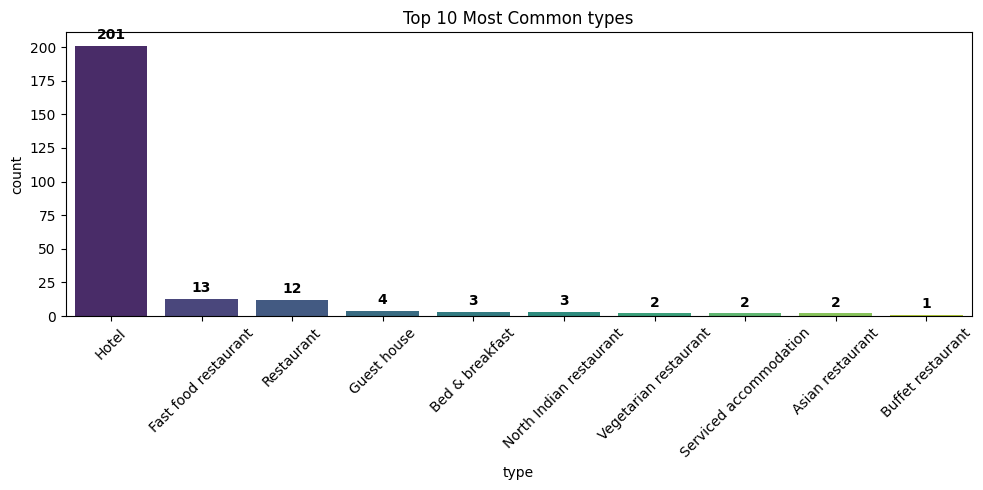

In [134]:
plt.figure(figsize=(10,5))
ax=sns.barplot(x="type", y="count", data=top10_type_df,palette="viridis")
# Annotate
for index, row in top10_type_df.iterrows():
    ax.text(row.name, row["count"] + 5, int(row["count"]), ha='center', fontweight='bold')


plt.title("Top 10 Most Common types")
plt.xlabel("type")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Pie Chart: Distribution of category**


category
hotels                     228
restaurants                 47
Guest house                  5
Bed & breakfast              4
North Indian restaurant      4
South Indian restaurant      2
Serviced accommodation       2
Dhaba                        2
Villa                        1
Punjabi restaurant           1
Homestay                     1
bars                         1
Mughlai restaurant           1
Name: count, dtype: int64


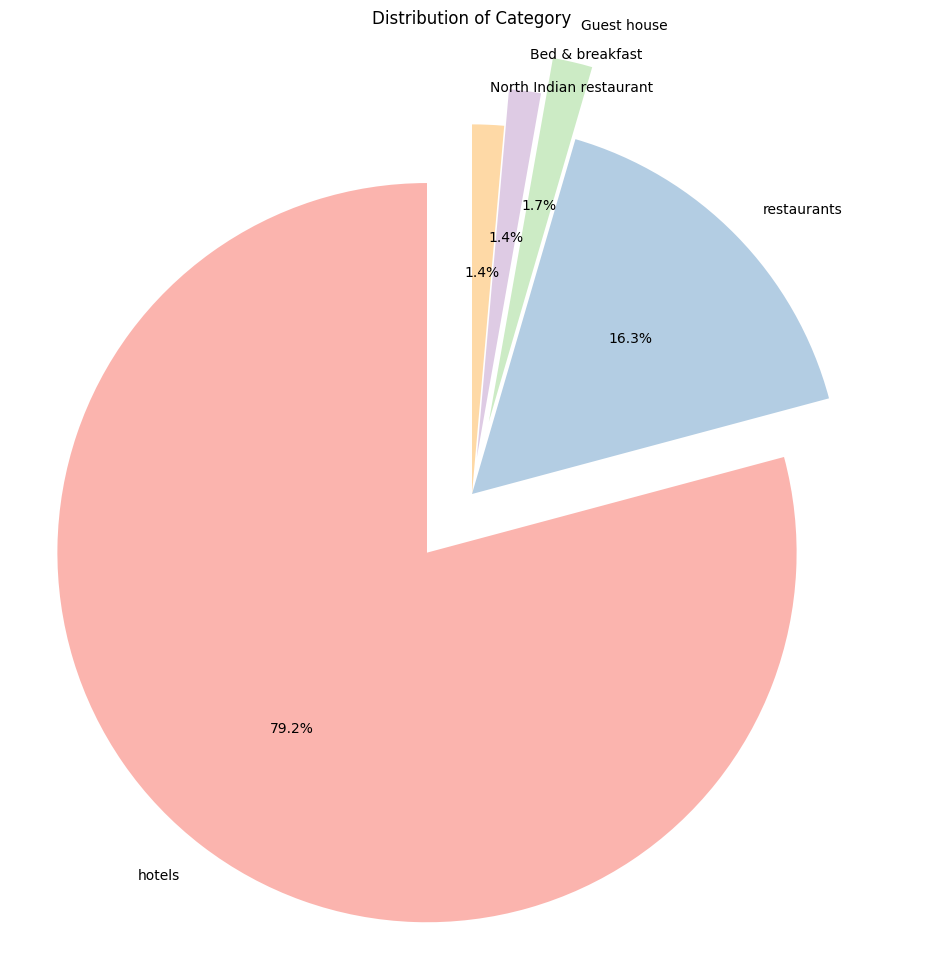

In [135]:
category_counts = df["category"].value_counts()
print(category_counts)
top5_cat = category_counts.head(5)
explode = [0.2, 0, 0.2, 0.1, 0]
plt.figure(figsize=(12,12))
plt.pie(
    top5_cat.values,
    labels=top5_cat.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Pastel1.colors,
    explode=explode
)

plt.title("Distribution of Category")
plt.show()

**Scatter bold text Plot: Reviews vs Rating, highlight rating >= 4.5 and reviews > 200**

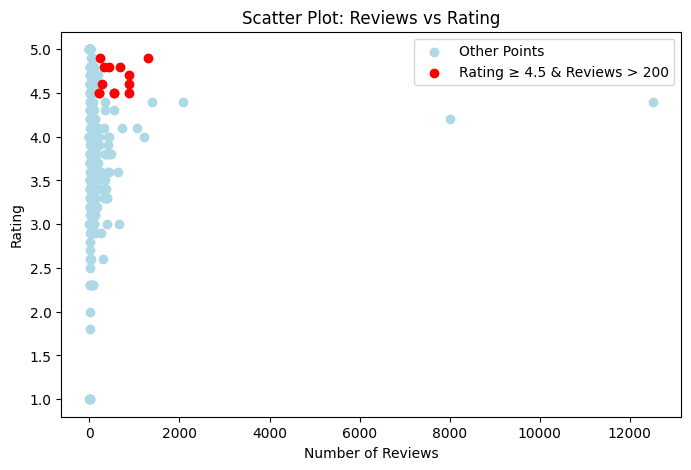

In [136]:
mask = (df["rating"] >= 4.5) & (df["reviews"] > 200)

plt.figure(figsize=(8,5))

# Plot all points in light grey
plt.scatter(
    df["reviews"],
    df["rating"],
    color="lightblue",
    label="Other Points"
)

# Plot highlighted points
plt.scatter(
    df.loc[mask, "reviews"],
    df.loc[mask, "rating"],
    color="red",
    label="Rating ≥ 4.5 & Reviews > 200"
)

plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.title("Scatter Plot: Reviews vs Rating")
plt.legend()
plt.show()

**Histogram: Ratings distribution.**

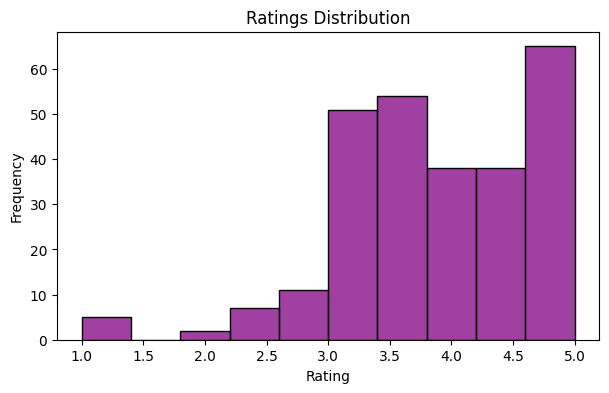

In [137]:
plt.figure(figsize=(7,4))
sns.histplot(df["rating"], bins=10, color="purple", edgecolor="black")

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# **Business Insights**

**Identify high potential clients: nearby, high reviews, rating >= 4.2**

In [138]:
high_potential_clients=target_df[(target_df['distance_from_office (in km.)']<20) & (target_df["reviews"]>200) & (df["rating"] >= 4.2)]
print("High potential clients :\n")
high_potential_clients




High potential clients :



,name,subtypes,category,type,phone,full_address,borough,postal_code,latitude,longitude,...,reviews,photos_count,business_status,range,verified,owner_id,Locality,latitude_rad,longitude_rad,distance_from_office (in km.)
26,Hotel City Park- Hotels in Delhi,Hotel,hotels,Hotel,+91 11 4231 0101,"City Park, Adarsh Nagar, Block KP, Poorvi Pita...","Adarsh Nagar, Block KP, Poorvi Pitampura, Pita...",110034,28.705488,77.143375,...,8002.0,1908.0,OPERATIONAL,4 stars,True,102765621762449261192,Pitampura,0.501005,1.346406,19.43
50,Hotel Season Grand Couple Friendly RoomsBest H...,"Extended stay hotel, Guest house, Gym, Hotel, ...",hotels,Extended stay hotel,+91 90153 90888,"House No 168 . 2nd floor, Ashiyana chowk, near...","Kapil Vihar, Pitampura",110034,28.700207,77.135717,...,1293.0,112.0,OPERATIONAL,0 star,True,102583307421388072352,Pitampura,0.500913,1.346272,19.73
51,Hotel O Leo Saffron By F Hotels,Hotel,hotels,Hotel,N/A,HOUSE NO RP - 7 PLOT NO 7 GROUND FLOOR BLK-RP ...,"Block RP, LANDMARK, Pitampura",110088,28.700657,77.150267,...,539.0,88.0,OPERATIONAL,3 stars,True,114120022906956641627,Pitampura,0.500921,1.346526,18.57
52,Saltstayz Select - Pitampura,Hotel,hotels,Hotel,+91 88000 40368,"No. B-157, Lok Vihar, Pitampura, New Delhi, De...","Block B, Lok Vihar, Pitampura",110034,28.693725,77.135093,...,887.0,62.0,OPERATIONAL,0 star,True,116641043000359069190,Pitampura,0.500800,1.346261,19.42
163,Exotica Heritage,Resort hotel,hotels,Resort hotel,+91 1800 313 2219,"416, Pearls Omaxe Tower, Netaji Subhash Place,...","Netaji Subhash Place, Shakurpur",110034,28.690584,77.151797,...,350.0,68.0,OPERATIONAL,0 star,True,116472241757528940553,Shakurpur,0.500745,1.346553,17.84


In [139]:
high_potential_clients=target_df[(target_df['distance_from_office (in km.)']<20) & (target_df["reviews"]>200) & (df["rating"] >= 4.2)]
print("High potential clients :\n")
top10_high_potential_clients=high_potential_clients.head(10)
top10_high_potential_clients

High potential clients :



,name,subtypes,category,type,phone,full_address,borough,postal_code,latitude,longitude,...,reviews,photos_count,business_status,range,verified,owner_id,Locality,latitude_rad,longitude_rad,distance_from_office (in km.)
26,Hotel City Park- Hotels in Delhi,Hotel,hotels,Hotel,+91 11 4231 0101,"City Park, Adarsh Nagar, Block KP, Poorvi Pita...","Adarsh Nagar, Block KP, Poorvi Pitampura, Pita...",110034,28.705488,77.143375,...,8002.0,1908.0,OPERATIONAL,4 stars,True,102765621762449261192,Pitampura,0.501005,1.346406,19.43
50,Hotel Season Grand Couple Friendly RoomsBest H...,"Extended stay hotel, Guest house, Gym, Hotel, ...",hotels,Extended stay hotel,+91 90153 90888,"House No 168 . 2nd floor, Ashiyana chowk, near...","Kapil Vihar, Pitampura",110034,28.700207,77.135717,...,1293.0,112.0,OPERATIONAL,0 star,True,102583307421388072352,Pitampura,0.500913,1.346272,19.73
51,Hotel O Leo Saffron By F Hotels,Hotel,hotels,Hotel,N/A,HOUSE NO RP - 7 PLOT NO 7 GROUND FLOOR BLK-RP ...,"Block RP, LANDMARK, Pitampura",110088,28.700657,77.150267,...,539.0,88.0,OPERATIONAL,3 stars,True,114120022906956641627,Pitampura,0.500921,1.346526,18.57
52,Saltstayz Select - Pitampura,Hotel,hotels,Hotel,+91 88000 40368,"No. B-157, Lok Vihar, Pitampura, New Delhi, De...","Block B, Lok Vihar, Pitampura",110034,28.693725,77.135093,...,887.0,62.0,OPERATIONAL,0 star,True,116641043000359069190,Pitampura,0.500800,1.346261,19.42
163,Exotica Heritage,Resort hotel,hotels,Resort hotel,+91 1800 313 2219,"416, Pearls Omaxe Tower, Netaji Subhash Place,...","Netaji Subhash Place, Shakurpur",110034,28.690584,77.151797,...,350.0,68.0,OPERATIONAL,0 star,True,116472241757528940553,Shakurpur,0.500745,1.346553,17.84


**Areas/locations comprising most of the potential customers**

In [140]:
area_counts = target_df.groupby("Locality")["name"].count().reset_index(name="potential_customers")
area_counts["percentage"] = round((area_counts["potential_customers"] / area_counts["potential_customers"].sum()) * 100,2)

print(area_counts)
max_cust_area=area_counts.sort_values(by=["percentage"],ascending=False)
print("\nMaximum no. of potential customers :\n"
"-----------------------------------\n",max_cust_area.head(1))

                         Locality  potential_customers  percentage
0                    Adarsh Nagar                   12         4.8
1                     Ashok Vihar                    5         2.0
2                         Azadpur                    8         3.2
3                         Bhalswa                    3         1.2
4                      Budh Vihar                    4         1.6
5                          Burari                    1         0.4
6                       Extension                    1         0.4
7                    Jahangirpuri                    9         3.6
8                      Karol Bagh                    1         0.4
9                     Khera Kalan                    2         0.8
10                     Mangolpuri                   24         9.6
11              Mansarover Garden                    1         0.4
12                          Metro                    2         0.8
13                      Mubarkpur                    1        

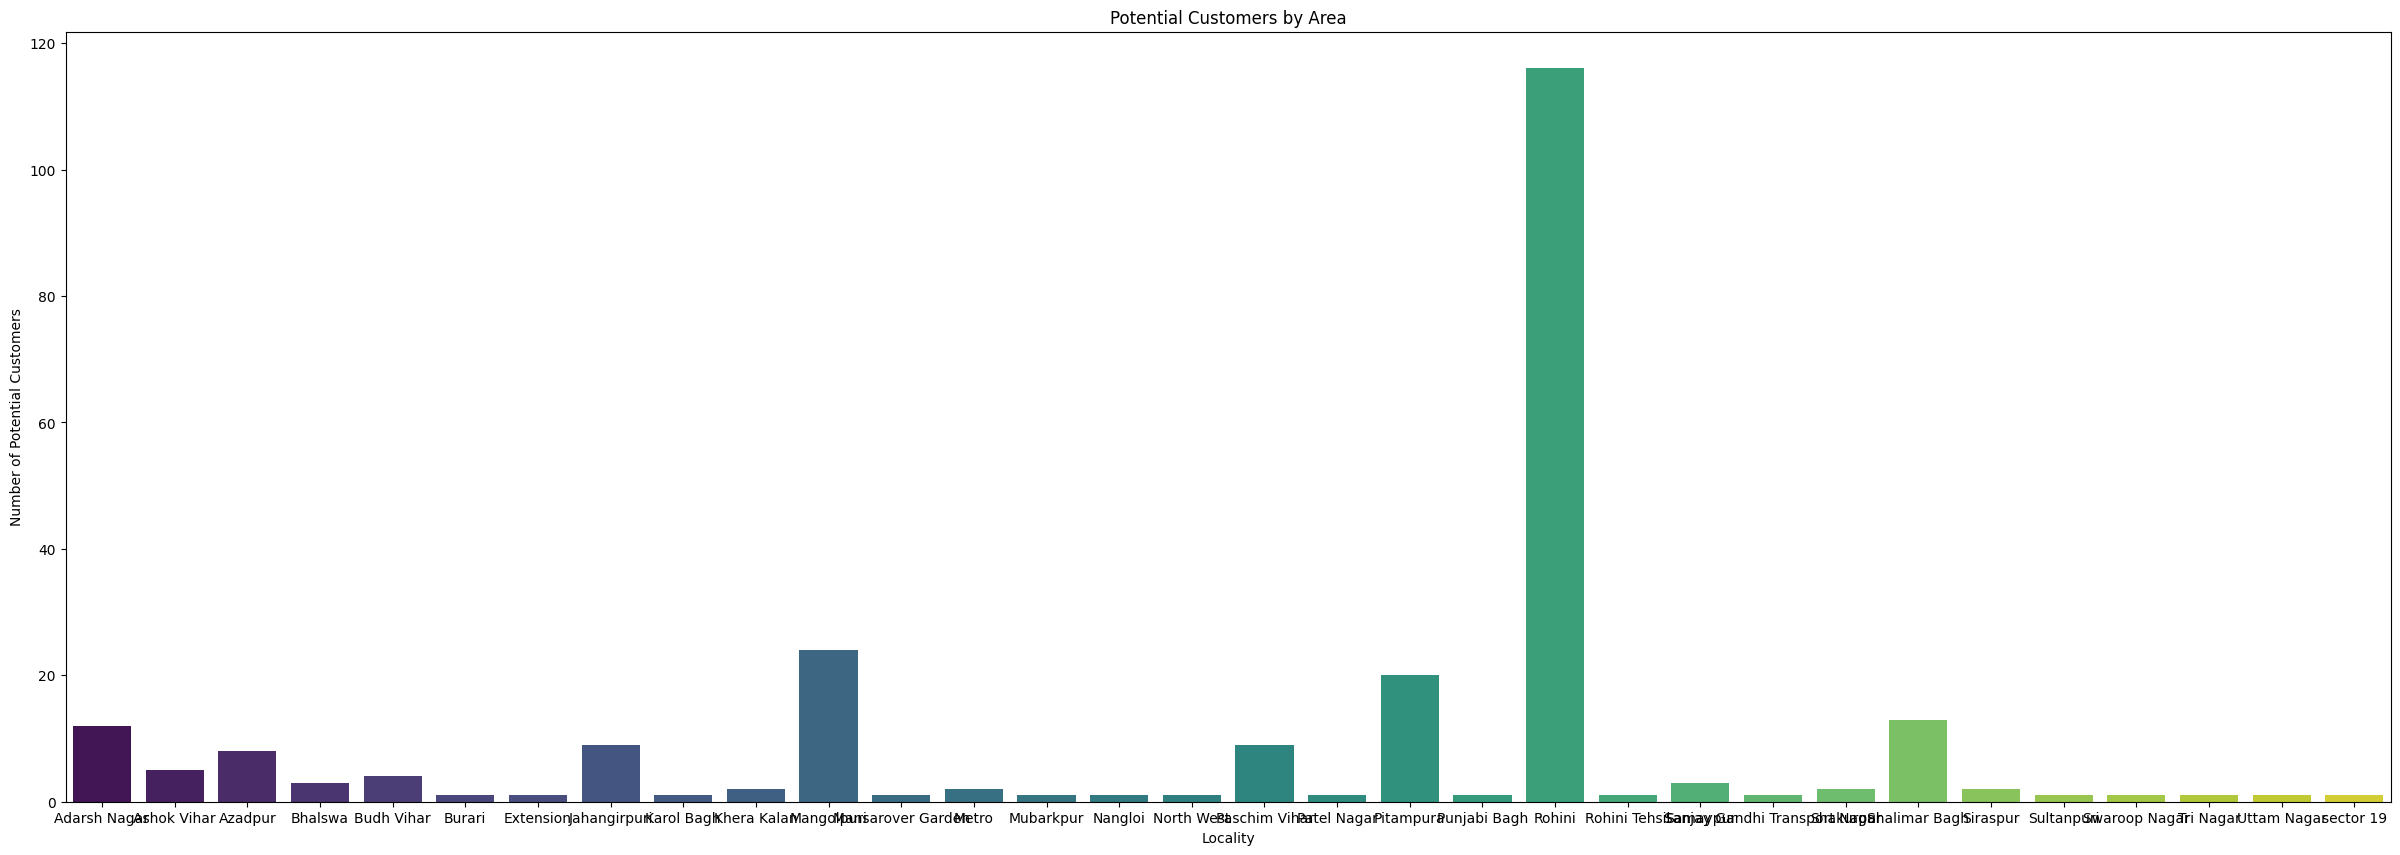

In [141]:
plt.figure(figsize=(30,10))
sns.barplot(
    data=area_counts,
    x="Locality",
    y="potential_customers",
    palette="viridis"
)

plt.xlabel("Locality")
plt.ylabel("Number of Potential Customers")
plt.title("Potential Customers by Area")
plt.show()

From the above analysis it is found that Rohini area contains maximum number of potential customers

**potential targets based on locality="Rohini"**

In [142]:
high_potential_clients_Rohini=target_df[(target_df['Locality']=='Rohini') & (target_df["reviews"]>200) & (df["rating"] >= 4.2)]
top_10_pot_clients_Rohini=high_potential_clients_Rohini.sort_values(by="rating",ascending=False)
top_10_pot_clients_Rohini.head(10)


,name,subtypes,category,type,phone,full_address,borough,postal_code,latitude,longitude,...,reviews,photos_count,business_status,range,verified,owner_id,Locality,latitude_rad,longitude_rad,distance_from_office (in km.)
15,Skymax Hotel,Hotel,hotels,Hotel,+91 98682 32370,"C-1, 189-190, Rammurti Passi Marg, Sector 11, ...","Pocket 1, Sector 11, Rohini",110085,28.730765,77.117177,...,229.0,31.0,OPERATIONAL,0 star,True,118176410483500391618,Rohini,0.501446,1.345949,23.14
39,Qotel Express Sandberry - Prashant Vihar,Hotel,hotels,Hotel,N/A,"ED Block, Prashant Vihar, Sector 14, Rohini, D...","Prashant Vihar, Sector 14, Rohini",110085,28.713040,77.138036,...,280.0,63.0,OPERATIONAL,0 star,True,110330923174531739116,Rohini,0.501137,1.346313,20.34
5,Qotel Comfort Church House Rohini Sector 15,Hotel,hotels,Hotel,+91 92055 95900,"1st Floor, Above Axis Bank, Plot no. 2, Pocket...","Sector 15H, Rohini",110085,28.731491,77.134014,...,880.0,80.0,OPERATIONAL,0 star,True,113204699662676572622,Rohini,0.501459,1.346243,21.89
283,Cafe DEM Restaurant & Bar,"Mughlai restaurant, Bar, Chinese restaurant, N...",Mughlai restaurant,Mughlai restaurant,+91 84479 48808,"Adventure Island, Swarn Jayanti Park, Sector 1...","Swarn Jayanti Park, Sector 10, Rohini",110039,28.724135,77.113599,...,553.0,348.0,OPERATIONAL,0 star,True,109746381063865743344,Rohini,0.501331,1.345886,23.00
0,GALLIVANTO INN,"Hotel, Bed & breakfast, Guest house, Inn, Lodg...",hotels,Hotel,+91 98117 66161,"Building no- 60, near primary school, Badli, R...","Badli, Rohini",110042,28.736676,77.144052,...,875.0,430.0,OPERATIONAL,0 star,True,118239119981341564511,Rohini,0.501550,1.346418,21.53
40,"FabExpress Rama - Hotel in Rohini, New Delhi",Hotel,hotels,Hotel,+91 70424 24242,"Plot No. 10, Pocket 27, Sector-24, Rohini, New...","Pocket 27, Sector-24, Rohini",110085,28.733200,77.086740,...,543.0,76.0,OPERATIONAL,3 stars,True,102586025125353205772,Rohini,0.501489,1.345417,25.73
8,Gallivanto Inn - Rohini,"Hotel, Guest house, Inn, Motel, Home Stay",hotels,Hotel,+91 98917 66161,"H, 3/27, Block A, Sector 18, Rohini, Delhi, 11...","Block A, Sector 18, Rohini",110089,28.740893,77.133186,...,214.0,111.0,OPERATIONAL,0 star,True,116601179594735907143,Rohini,0.501623,1.346228,22.63
2,AP Holidays,Hotel,hotels,Hotel,+91 92189 21855,"Plot No. 8, Pocket 8B, YES Bank Building, Sect...","Sector 15, Rohini",110085,28.730078,77.132723,...,1394.0,358.0,OPERATIONAL,3 stars,True,100933720747463948997,Rohini,0.501434,1.346220,21.89
36,Crowne Plaza New Delhi Rohini by IHG,"Hotel, Conference center, Wedding venue",hotels,Hotel,+91 11 4488 4488,"Twin District Centre, Swarn Jayanti Park, Sect...","Swarn Jayanti Park, Sector 10, Rohini",110085,28.719871,77.109772,...,12517.0,10840.0,OPERATIONAL,5 stars,True,101113492558625456456,Rohini,0.501256,1.345819,23.04
201,Seventh Sense - All Day Dining Restaurant,"Buffet restaurant, Restaurant",restaurants,Buffet restaurant,+91 11 4340 0008,"Seven Seas Hotel, Located Inside, 12, Mangalam...","Mangalam Place, Rohini",110085,28.700412,77.115400,...,2082.0,394.0,OPERATIONAL,₹₹,True,109154570042541458333,Rohini,0.500917,1.345918,21.46


### **Group by city/area/locality, find average ratings**

In [143]:
avg_ratings=target_df.groupby("Locality")["rating"].mean().reset_index()
avg_ratings=round(avg_ratings,2)
avg_ratings.sort_values(by=["rating"],ascending=False)

,Locality,rating
5,Burari,5.00
30,Uttam Nagar,5.00
26,Siraspur,4.85
24,Shakurpur,4.70
27,Sultanpuri,4.50
9,Khera Kalan,4.50
28,Swaroop Nagar,4.50
3,Bhalswa,4.25
10,Mangolpuri,4.23
19,Punjabi Bagh,4.00


### **Flag clients with zero photos or reviews**

In [144]:
target_df["zero_photos_reviews"]=(target_df["photos_count"]==0)|(target_df["reviews"]==0)
target_df.head(10)

,name,subtypes,category,type,phone,full_address,borough,postal_code,latitude,longitude,...,photos_count,business_status,range,verified,owner_id,Locality,latitude_rad,longitude_rad,distance_from_office (in km.),zero_photos_reviews
0,GALLIVANTO INN,"Hotel, Bed & breakfast, Guest house, Inn, Lodg...",hotels,Hotel,+91 98117 66161,"Building no- 60, near primary school, Badli, R...","Badli, Rohini",110042,28.736676,77.144052,...,430.0,OPERATIONAL,0 star,True,118239119981341564511,Rohini,0.501550,1.346418,21.53,False
2,AP Holidays,Hotel,hotels,Hotel,+91 92189 21855,"Plot No. 8, Pocket 8B, YES Bank Building, Sect...","Sector 15, Rohini",110085,28.730078,77.132723,...,358.0,OPERATIONAL,3 stars,True,100933720747463948997,Rohini,0.501434,1.346220,21.89,False
3,Hotel Park Lane,Asian restaurant,restaurants,Asian restaurant,N/A,"Pocket 8(B, Plot 2, next to Saroj Hospital, Se...","Sector 19, Rohini",110089,28.733690,77.139556,...,19.0,OPERATIONAL,0 star,True,103541183885314268765,Rohini,0.501498,1.346339,21.64,False
4,"FabHotel The Chaitanyas - Hotel in Rohini, New...",Hotel,hotels,Hotel,+91 70424 24242,"H-3/25, Sector 18, Rohini, New Delhi, Delhi, 1...","Sector 18, Rohini",110089,28.740660,77.133200,...,56.0,OPERATIONAL,3 stars,True,118356555945716883295,Rohini,0.501619,1.346228,22.61,False
5,Qotel Comfort Church House Rohini Sector 15,Hotel,hotels,Hotel,+91 92055 95900,"1st Floor, Above Axis Bank, Plot no. 2, Pocket...","Sector 15H, Rohini",110085,28.731491,77.134014,...,80.0,OPERATIONAL,0 star,True,113204699662676572622,Rohini,0.501459,1.346243,21.89,False
6,FabHotel Church House Rohini - Hotel in Rohini...,Hotel,hotels,Hotel,+91 70424 24242,"1st Floor, New Delhi, Delhi 110085","Sector 15, Pocket 1, Sector 15C, Rohini",110085,28.731522,77.133804,...,62.0,OPERATIONAL,3 stars,True,105454317649265173260,Rohini,0.501460,1.346239,21.91,False
8,Gallivanto Inn - Rohini,"Hotel, Guest house, Inn, Motel, Home Stay",hotels,Hotel,+91 98917 66161,"H, 3/27, Block A, Sector 18, Rohini, Delhi, 11...","Block A, Sector 18, Rohini",110089,28.740893,77.133186,...,111.0,OPERATIONAL,0 star,True,116601179594735907143,Rohini,0.501623,1.346228,22.63,False
9,The Arrow Hotel,Hotel,hotels,Hotel,+91 79033 74080,"I6, 92, Ram Krishna Marg, Pocket 6, Sector 16,...","Pocket 6, Sector 16, Rohini",110089,28.741281,77.121053,...,85.0,OPERATIONAL,0 star,True,103904819838627941565,Rohini,0.501630,1.346016,23.56,False
11,Itsy Hotels Prime Stay,"Hotel, Guest house, Inn, Lodge, Motel, Service...",hotels,Hotel,+91 93228 00100,"Pocket-8B, Plot No. 3, Jail Road, Sector 19, R...","Sector 19, Rohini",110085,28.733694,77.139552,...,88.0,OPERATIONAL,3 stars,True,117471555734524928482,Rohini,0.501498,1.346339,21.64,False
12,Super Townhouse Mannat Rohini 16,"Hotel, Bed & breakfast, Guest house, Inn, Lodg...",hotels,Hotel,+91 124 620 1616,"I6, Tehsil 92, Ram Krishna Marg, Pocket 6, Sec...","Pocket 6, Sector 16, Rohini",110089,28.741334,77.121158,...,61.0,OPERATIONAL,0 star,True,111302206476984289610,Rohini,0.501631,1.346018,23.56,False


### **Group by subtype and find highest rated categories**

In [145]:
idx = target_df.groupby("subtypes")["rating"].idxmax()
highest_rated = target_df.loc[idx, ["subtypes", "category", "rating"]].reset_index(drop=True)
print("\nHighest rated category in each subtype:")
highest_rated


Highest rated category in each subtype:


,subtypes,category,rating
0,Asian restaurant,restaurants,4.4
1,"Asian restaurant, Continental restaurant, Ital...",restaurants,4.0
2,Bar,bars,4.2
3,"Bed & breakfast, Event venue",Bed & breakfast,4.0
4,"Bed & breakfast, Guest house",Bed & breakfast,3.7
5,"Bed & breakfast, Hotel",Bed & breakfast,4.1
6,"Buffet restaurant, Restaurant",restaurants,4.4
7,"Extended stay hotel, Guest house, Gym, Hotel, ...",hotels,4.9
8,Fast food restaurant,restaurants,5.0
9,"Fast food restaurant, Indian restaurant",restaurants,3.9


**Export these to Excel  top 10 potential clients list with name, phone, and address**

In [147]:
top_10_pot_clients_Rohini=top_10_pot_clients_Rohini.head(10)
export_to_excel=top_10_pot_clients_Rohini[["name","phone","full_address"]]
export_to_excel.to_excel("Top10_Potential_Customer.xlsx",index=False)

# **Summary of insights and top clients**
*   from data it is observed that "hotels,restaurants & Guest house" can be top potential customers.
*   "business_status" column contains "CLOSED_TEMPORARILY" status which can be removed as it may lead to irrelevant potential customer identification.
*  "verified" column contains "FALSE" which means the customer is not verified on google and can be ignored.
*   entities having high ratings, more number of reviews and geographically nearby to the company can be potential customers.
*   from data it is evident that "Rohini" area has more number of customers which can be target for potential customers.



